In [119]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/sample_data/zomato_restaurants.csv")

# First 5 rows
print(df.head())

# Dataset information
print(df.info())

# Statistical summary
print(df.describe())

  restaurant_name       cuisine     location  cost  rating
0       Spice Hub  North Indian  Navrangpura   500     4.3
1     Pizza Point       Italian    Satellite   800     4.1
2      Food Court       Chinese    Maninagar   300     3.8
3       Cafe Brew          Cafe      CG Road   650     4.5
4      Dosa House  South Indian        Paldi   250     3.9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   restaurant_name  12 non-null     object 
 1   cuisine          12 non-null     object 
 2   location         12 non-null     object 
 3   cost             12 non-null     int64  
 4   rating           12 non-null     float64
dtypes: float64(1), int64(1), object(3)
memory usage: 612.0+ bytes
None
              cost     rating
count    12.000000  12.000000
mean    529.166667   4.100000
std     279.982413   0.316228
min     200.000000   3.600000


restaurant_name    0
cuisine            0
location           0
cost               0
rating             0
dtype: int64


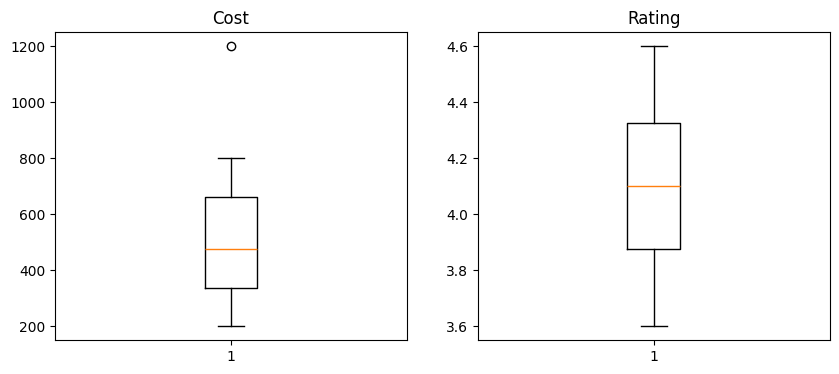

Data after removing outliers:
  restaurant_name       cuisine     location  cost  rating
0       Spice Hub  North Indian  Navrangpura   500     4.3
1     Pizza Point       Italian    Satellite   800     4.1
2      Food Court       Chinese    Maninagar   300     3.8
3       Cafe Brew          Cafe      CG Road   650     4.5
4      Dosa House  South Indian        Paldi   250     3.9


In [120]:
import numpy as np
import matplotlib.pyplot as plt

# Missing values
print(df.isnull().sum())

# Fill missing values if any
df["cost"] = df["cost"].fillna(df["cost"].median())
df["rating"] = df["rating"].fillna(df["rating"].median())

# Boxplots
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.boxplot(df["cost"])
plt.title("Cost")

plt.subplot(1,2,2)
plt.boxplot(df["rating"])
plt.title("Rating")

plt.show()

# IQR Method for Cost
Q1 = df["cost"].quantile(0.25)
Q3 = df["cost"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["cost"] >= lower) & (df["cost"] <= upper)]

print("Data after removing outliers:")
print(df.head())

In [122]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# One-hot encode
df = pd.get_dummies(df, columns=["cuisine", "location"])

# Scale numerical columns
scaler = StandardScaler()

df[["cost", "rating"]] = scaler.fit_transform(df[["cost", "rating"]])

print(df.head())

  restaurant_name      cost    rating  cuisine_Biryani  cuisine_Cafe  \
0       Spice Hub  0.173170  0.895041            False         False   
1     Pizza Point  1.805913  0.165748            False         False   
2      Food Court -0.915326 -0.928191            False         False   
3       Cafe Brew  0.989541  1.624334            False          True   
4      Dosa House -1.187450 -0.563545            False         False   

   cuisine_Chinese  cuisine_Desserts  cuisine_Fast Food  cuisine_Gujarati  \
0            False             False              False             False   
1            False             False              False             False   
2             True             False              False             False   
3            False             False              False             False   
4            False             False              False             False   

   cuisine_Italian  cuisine_Mexican  cuisine_North Indian  \
0            False            False        

In [123]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Create target variable
df["target"] = (df["rating"] > 0).astype(int)

X = df.drop(["restaurant_name", "target"], axis=1)
y = df["target"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)

lr_prob = lr.predict_proba(X_test)[:,1]
lr_auc = roc_auc_score(y_test, lr_prob)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_prob = rf.predict_proba(X_test)[:,1]
rf_auc = roc_auc_score(y_test, rf_prob)

print("Logistic Regression ROC-AUC:", lr_auc)
print("Random Forest ROC-AUC:", rf_auc)

if rf_auc > lr_auc:
    print("Random Forest performed better.")
else:
    print("Logistic Regression performed better.")

Logistic Regression ROC-AUC: 1.0
Random Forest ROC-AUC: 1.0
Logistic Regression performed better.


In [124]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

# Balance dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Parameter grid
params = {
    "n_estimators": [50, 100],
    "max_depth": [3, 5, None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    scoring="roc_auc",
    cv=3
)

grid.fit(X_resampled, y_resampled)

print("Best Parameters:")
print(grid.best_params_)

print("Best ROC-AUC:")
print(grid.best_score_)

Best Parameters:
{'max_depth': 3, 'n_estimators': 50}
Best ROC-AUC:
0.5
